# 1. Modelling

## 1.1. Importing Libraries, Modules, and Feature lists

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

%store -r features_to_transform
%store -r features

## 1.2. Loding Data

In [2]:
df = pd.read_csv('../data/clean_data.csv', index_col=[0])

df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
1,6762810635,42491,4,2.50,7.979681,8.294300,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,7.812378,8.294300,2,51,14.151984
2,6762810998,42491,5,2.75,7.976252,9.157045,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,7.986505,8.794976,1,53,13.997833
4,6762812919,42491,3,2.00,7.905073,8.412055,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,7.630947,8.412055,1,51,13.598599
5,6762813105,42491,3,2.50,7.863651,8.466110,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,7.775276,8.466110,1,67,13.579789
6,6762813157,42491,5,3.25,8.205492,9.392329,2.0,0,2,3,...,2006,0,122008,52.7637,-114.050,8.108021,9.327412,3,72,13.573440


## 1.3. Splitting Data into Train and Test sets

In [3]:
X = df[features]
y = (df['Price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## 1.4. Defining Modules for Model

### 1.4.1 Defining Function to be used for Log Transformer

In [4]:
def log_transform_func(X):
    # Use np.log1p for numerical stability (handles zero values)
    return np.log1p(X)

def inverse_log_transform_func(X):
    return np.expm1(X)

### 1.4.2 Defining Log Transformer, Preprocessor, and Pipeline for our Model

In [5]:
log_transformer = FunctionTransformer(
    func=log_transform_func,
    inverse_func=inverse_log_transform_func,
    validate=True
)

preprocessor = ColumnTransformer(
    transformers=[
        ('log_transform', log_transformer, features_to_transform)
    ],
    remainder='passthrough' # Pass through the other features
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, max_depth=30)) # After testing multiple hyperparameters for our regressor, this was the best set
    ]
)

### 1.4.3 Building and Training our Model
---
We will use *TransformedTargetRegressor* so we can automate our target variable log transformatuion and inverse transformation, while pipeline handles prior.

In [6]:
model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

model.fit(X_train, y_train)

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(


TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('log_transform',
                                                                                       FunctionTransformer(func=<function log_transform_func at 0x00000182F2F12FC0>,
                                                                                                           inverse_func=<function inverse_log_transform_func at 0x00000182F2F13060>,
                                                                                                           validate=True),
                                                                                       ['living_area_renov',
                                                                                        'Area '
                                                                                        'of '
                                                                                        'the '
                                                                                        'house(excluding '
                                                                                        'basement)',
                                                                                        'living '
                                                                                        'area'])])),
                                                     ('regressor',
                                                      RandomForestRegressor(max_depth=30))]))

# 2. Evaluation

## 2.1. Metrics Evaluation
---
We will use following metrics:
- **R2 Score** - Quantifies the proportion of variance in the target variables explained by the features relative to a mean baseline
- **Mean Squared Error** - It heavily penalizes large residuals to measure the model's sensitivity to outliers
- **Mean Absolute Error** - Measures the average magnitude of errors in the target's original units, offering a linear interpretation of model bias.
- **Mean Absolute Percentage Error** - Normalizes the error by the actual values to provide a scale-invariant percentage of the relative prediction offset

In [7]:
y_pred = model.predict(X_test)

# Inversing the log values of test and prediction series
y_test_in = model.inverse_func(y_test)
y_pred_in = model.inverse_func(y_pred)

print(f"R2 Score: {r2_score(y_test_in, y_pred_in):.4f}")
print(f"MSE: {mean_squared_error(y_test_in, y_pred_in):.4f}")
print(f"MAE: {mean_absolute_error(y_test_in, y_pred_in):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test_in, y_pred_in):.4f}")

R2 Score: 0.8121
MSE: 13592384279.0201
MAE: 72632.7566
MAPE: 0.1413


### Results
---
- **R2 Score** - The model accounts for **81% of the total variance,** indicating a strong fit with high predictive power for the target distribution.
- **Mean Squared Error** - The extreme magnitude reflects **high-variance errors** on the upper-bound samples, where squared residuals scale exponentially.
- **Mean Absolute Error** - On average, the model's absolute deviation from the ground price is **72632.75 dollars,** demonstrating high precision relative to the extreme scale of target variable.
- **Mean Absolute Percentage Error** - The model maintains an **average relative error of 14.13%,** providing consistent performance across different price strata.

## 2.2. Plotting Actual vs Predicted Prices

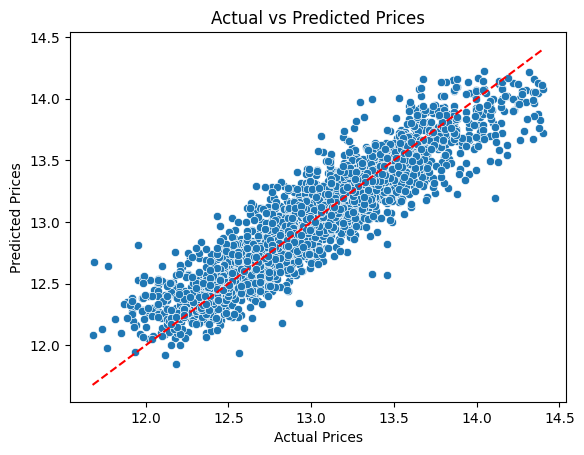

In [8]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.savefig('../outputs/notebook 2/actual vs predicted prices.png')
plt.show()
plt.close()

## 2.3. Top Features respective to their Importance

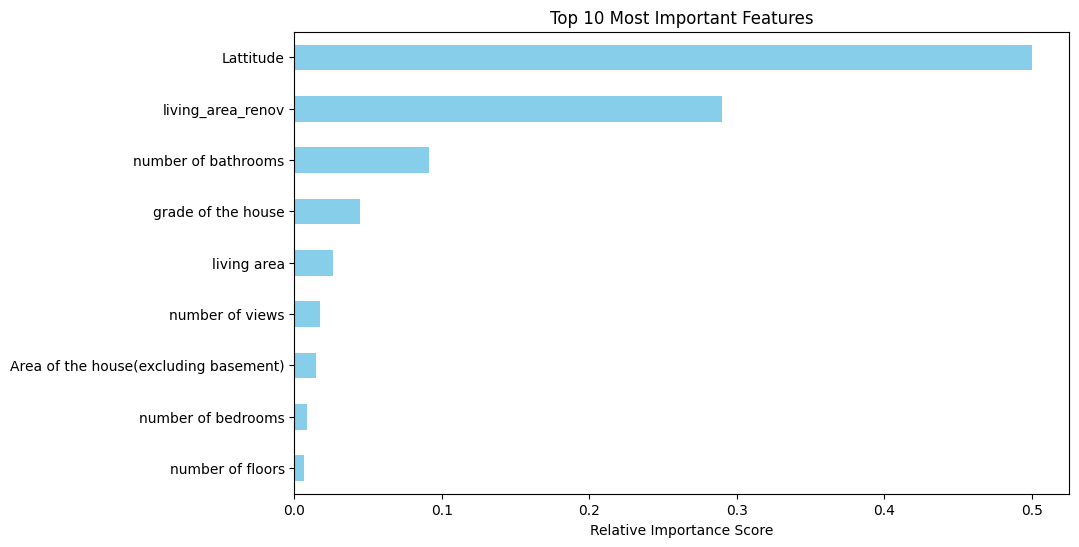

In [9]:
importances = model.regressor_['regressor'].feature_importances_
feat_importances = pd.Series(importances, index=features)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Important Features')
plt.xlabel('Relative Importance Score')
plt.gca().invert_yaxis() # Highest importance at the top
plt.savefig('../outputs/notebook 2/top_features.png')
plt.show()
plt.close()

# 3. Saving The Model

In [10]:
joblib.dump(model, "model/model.pkl")

['model/model.pkl']